In [1]:
#MODULE 1
"""
Calculates reduced potential energy and force magnitude for a pair
of atoms .
TASK : Use the equations to implement the Lennard - Jones potential and
force .
REQUIREMENTS :
1. Implement the shifted potential : phi (r) - phi (rc).
2. Return the force magnitude divided by r ( force /r).
"""
import numpy as np
def calculate_lj_properties ( r_sq , r_cutoff_sq ) :
  if(r_sq>r_cutoff_sq):
    return 0,0
  lj_p1=4*((1/r_sq)**6 -(1/r_sq)**3)
  lj_p2=4*((1/r_cutoff_sq)**6 -(1/r_cutoff_sq)**3)
  s_ljp=lj_p1-lj_p2
  F=(24*(2*(r_sq**-6)-r_sq**(-3)))/r_sq
  F_rc = (24 * (2*(r_cutoff_sq**-6) - r_cutoff_sq**(-3)))/r_cutoff_sq
  F_shifted = F - F_rc
  return s_ljp,F_shifted

CHECKING MODULE-1

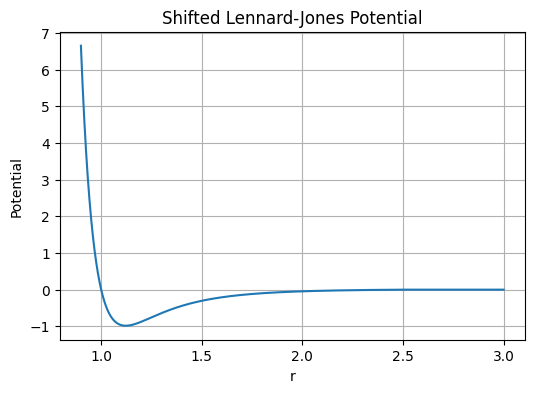

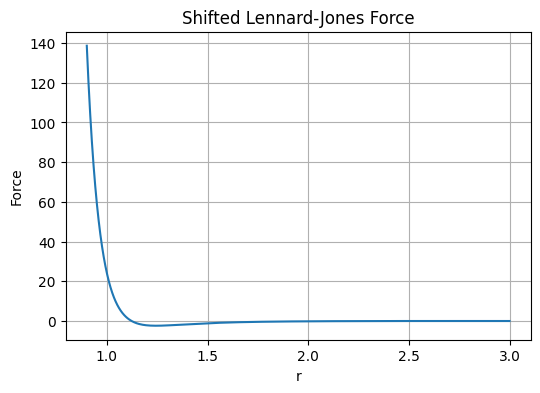

In [2]:
import numpy as np
import matplotlib.pyplot as plt

r_values = np.linspace(0.9, 3.0, 500)

potential = []
force = []

rc = 2.5
rc_sq = rc**2

for r in r_values:

    r_sq = r**2

    U, F_over_r = calculate_lj_properties(r_sq, rc_sq)

    potential.append(U)

    force.append(F_over_r * r)   # actual force magnitude

# Plot potential
plt.figure(figsize=(6,4))
plt.plot(r_values, potential)
plt.xlabel("r")
plt.ylabel("Potential")
plt.title("Shifted Lennard-Jones Potential")
plt.grid()
plt.show()

# Plot force
plt.figure(figsize=(6,4))
plt.plot(r_values, force)
plt.xlabel("r")
plt.ylabel("Force")
plt.title("Shifted Lennard-Jones Force")
plt.grid()
plt.show()

Observation:
Module-1 was verified by plotting the Lennard-Jones potential and force versus interatomic distance. The potential exhibited the expected repulsive and attractive regions with a minimum near the equilibrium distance(when dU/dr=0)=1.122, while the force showed correct repulsive and attractive behavior and approached zero near the cutoff distance. Hence, the implementation was confirmed to be correct.

In [3]:
# MODULE 2 part-1
"""
Generates an FCC lattice of atoms .
TASK :
1. Calculate the box length L based on density (rho = N/V).
2. Place 4 atoms in each of the n_cells ^3 unit cells .
"""
import numpy as np
def generate_fcc_lattice ( n_cells , rho_star ) :
  #lattice parameter is a
  #length of simulation cell will be na
  #rho star=4(n_cells**3)/V, Volume=n_cells**3 x a**3
  Volume= (4*(n_cells**3))/rho_star
  Length=(np.cbrt(Volume))
  a=Length/n_cells
  list1=[]
  posn=[(0,0,0),(0.5, 0.5, 0),(0.5, 0, 0.5),(0, 0.5, 0.5)]

  for i in range(0,n_cells):
    for j in range(0,n_cells):
      for k in range(0,n_cells):
        x0=i*a
        y0=j*a
        z0=k*a
        for p in posn:
          x=x0+ a* p[0]
          y=y0+a*p[1]
          z=z0+a*p[2]
          list1.append([x,y,z])

  return np.array(list1)

CHECKING MODULE-2 part-1

In [4]:
positions = generate_fcc_lattice(3, 0.8442)

print(len(positions))

108


observation: Since for FCC we have N=4xncells^3, the number of expected atoms is  4x(3^3)=108 which matches what we got

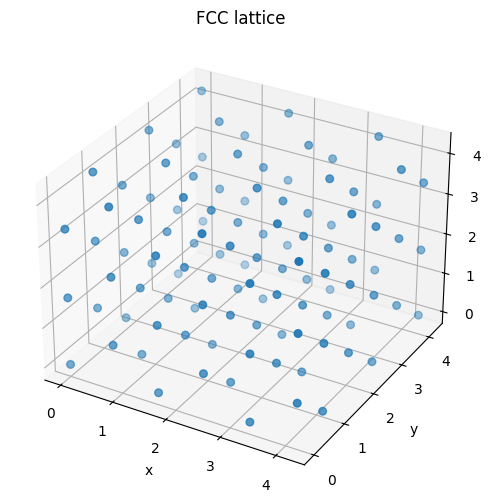

In [5]:
import matplotlib.pyplot as plt

positions = generate_fcc_lattice(3, 0.8442)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    positions[:,0],
    positions[:,1],
    positions[:,2],
    s=30
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.title("FCC lattice")
plt.show()

observation:
The generated structure is verified as FCC because the atomic positions follow the FCC basis vectors (0,0,0),(0.5, 0.5, 0),(0.5, 0, 0.5),(0, 0.5, 0.5)
 repeated periodically in 3D space. The visualization also shows the characteristic face-centered arrangement and close-packed layered structure expected for an FCC lattice.

In [6]:
from scipy.spatial.distance import pdist
import numpy as np

n_cells = 3
rho_star = 0.8442

positions = generate_fcc_lattice(n_cells, rho_star)

# compute box length
N = len(positions)
L = (N / rho_star)**(1/3)

a = L / n_cells

print("Expected nearest neighbor distance:")
print(a / np.sqrt(2))

distances = pdist(positions)

print("Actual minimum distance:")
print(np.min(distances))

Expected nearest neighbor distance:
1.187653856581669
Actual minimum distance:
1.1876538565816692


observation:The expected nearest neighbour distance and the actual  minimum distance match,confirming our atoms positions

In [7]:
#MODULE-2 part-2
"""
Calculates the shortest distance vector between two atoms .
TASK : Use the rounding logic to ensure dx ,
dy , and dz
are between -L/2 and L/2.
"""
def apply_minimum_image ( pos_i , pos_j , L ) :
  dist=pos_i-pos_j
  dx,dy,dz=dist-L*np.round(dist/L)
  return dx,dy,dz

CHECKING MODULE-2 part-2

In [8]:
import numpy as np

L = 10.0

pos_i = np.array([9.5, 1.0, 1.0])
pos_j = np.array([0.5, 1.0, 1.0])

dx, dy, dz = apply_minimum_image(pos_i, pos_j, L)

print(dx, dy, dz)

-1.0 0.0 0.0


observation:Here pos_i[0]-pos_j[0]=9, but because we applied minimum image convention we get -1 as the displacement

Hence, we verify that all parts of module-2 are correct

In [9]:
"""
Advances the system by one time step dt using Velocity Verlet .
TASK :
1. Update positions .
2. Apply Periodic Boundary Conditions ( wrap atoms back into box ).
3. Update velocities (half - step ).
4. Calculate new forces ( This will require your Module 1 & 2 logic ).
5. Update velocities (full - step ).
"""
#MODULE-3
# YOUR CODE HERE
# Step 1: New Positions
# pos_new = pos + vel*dt + 0.5* force *dt **2
# Step 2: PBC Wrap ( Module 2 logic )
# pos_new = pos_new % box_length
# Step 3: Half - step velocity
# vel_mid = vel + 0.5* force *dt
# Step 4: New Forces ( Call your Module 1 force function here )
# force_new = calculate_total_force ( pos_new , box_length )
# Step 5: Full - step velocity
# vel_new = vel_mid + 0.5* force_new *dt
import numpy as np
def calculate_total_force(pos_new,box_length):
  tot_particles=len(pos_new)
  forces=np.zeros_like(pos_new)
  r_cutoff=box_length/2.0
  r_cutoff_sq=r_cutoff**2
  for i in range(tot_particles-1):
    for j in range(i+1,tot_particles):
      dx,dy,dz=apply_minimum_image(pos_new[i],pos_new[j],box_length)
      r_sq=(dx*dx+dy*dy+dz*dz)
      if r_sq< r_cutoff_sq:
        _,force_over_r=calculate_lj_properties(r_sq, r_cutoff_sq)
        fx = force_over_r*dx
        fy=force_over_r*dy
        fz=force_over_r*dz
        forces[i][0]+=fx
        forces[i][1]+=fy
        forces[i][2]+=fz
        forces[j][0]-=fx
        forces[j][1]-=fy
        forces[j][2]-=fz
  return forces



# def velocity_verlet_step ( pos , vel , force , dt , box_length, ) :
#   pos_new=pos+ vel*dt+ 0.5*force*(dt**2)
#   pos_new=pos_new%box_length
#   vel_mid=vel+ 0.5*force*dt
#   force_new=calculate_total_force( pos_new,box_length)
#   vel_new=vel_mid+0.5*force_new*dt
#   return pos_new, vel_new, force_new




OPTIMISED VERSION FOR 4TH MODULE

In [10]:
def velocity_verlet_step ( pos , vel , force , dt , box_length,neighbor_pairs,r_cutoff_sq ) :
  pos_new=pos+ vel*dt+ 0.5*force*(dt**2)
  pos_new=pos_new%box_length
  vel_mid=vel+ 0.5*force*dt
  force_new=calculate_forces_optimized( pos_new, neighbor_pairs, box_length, r_cutoff_sq)
  vel_new=vel_mid+0.5*force_new*dt
  return pos_new, vel_new, force_new

In [11]:
import numpy as np

def update_neighbor_list(pos, L, r_cutoff, r_skin_sq):
    N = len(pos)



    diff = pos[:, np.newaxis, :] - pos[np.newaxis, :, :]
    diff = diff - L * np.round(diff / L)

    r_sq = np.sum(diff**2, axis=-1)

    i_idx, j_idx = np.triu_indices(N, k=1)

    mask = r_sq[i_idx, j_idx] < r_skin_sq

    pairs = list(zip(i_idx[mask], j_idx[mask]))

    return pairs

In [12]:
def compute_max_displacement(pos, pos_old, L):
    dr = pos - pos_old
    dr = dr - L * np.round(dr / L)

    disp = np.sqrt(np.sum(dr**2, axis=1))
    return np.max(disp)

In [13]:
import numpy as np

def calculate_forces_optimized(pos, neighbor_pairs, L, r_cutoff_sq):
    total_forces = np.zeros_like(pos)

    # Convert neighbor list to arrays
    pairs = np.array(neighbor_pairs)
    i_idx = pairs[:, 0]
    j_idx = pairs[:, 1]

    # Positions of pairs
    ri = pos[i_idx]
    rj = pos[j_idx]

    # Minimum image convention (vectorized)
    dr = ri - rj
    dr -= L * np.round(dr / L)

    # Squared distances
    r_sq = np.sum(dr**2, axis=1)

    # Apply cutoff mask
    mask = r_sq < r_cutoff_sq

    dr = dr[mask]
    r_sq = r_sq[mask]
    i_idx = i_idx[mask]
    j_idx = j_idx[mask]

    vectorized_lj_properties=np.vectorize(calculate_lj_properties,signature='(),()->(),()')
    _,force=vectorized_lj_properties(r_sq,r_cutoff_sq)





    # Multiply by displacement to get vector force
    forces = dr * force[:, np.newaxis]

    # Accumulate forces
    np.add.at(total_forces, i_idx, forces)
    np.add.at(total_forces, j_idx, -forces)

    return total_forces

In [14]:
# Module 5 CodingTask : System Assembly
"""
Assigns initial velocities from a Maxwell - Boltzmann distribution .
TASK :
1. Generate Gaussian random numbers for vx , vy , vz with std_dev =
sqrt ( T_target ).
2. Calculate total momentum and subtract the average from each
particle
so the center -of - mass is stationary .
"""
import numpy as np
def initialize_velocities (N , T_target ) :
  std_dev=np.sqrt(T_target)
  vel=np.random.normal(0.0,std_dev,size=(N,3))
  vcm=np.mean(vel,axis=0)
  vel=vel-vcm
  return vel


"""
Scales velocities to match the target temperature .
"""
# 1. Calculate current T_inst = (sum v^2) / 3N
# 2. Scale factor lambda = sqrt ( T_target / T_inst )
# 3. vel = vel * lambda
# --- YOUR CODE HERE ---
def rescale_velocities ( vel , T_target ) :
  N=len(vel)
  vsq_sum=np.sum(vel**2)
  T_inst=vsq_sum/(3*N)
  factor=np.sqrt(T_target/T_inst)
  vel=vel*factor
  return vel

In [33]:
# -----------------------------
# MAIN MD LOOP
# -----------------------------

# Define simulation parameters
n_cells = 4 # Number of unit cells in each dimension
rho_star = 1  # Reduced density
T_target = 0.5  # Target reduced temperature
dt = 0.005  # Time step
skin = 0.3  # Neighbor list skin distance

# (a) INITIALIZATION (Done via modules)
pos = generate_fcc_lattice(n_cells, rho_star)
N = len(pos)
box_length = (N / rho_star)**(1/3)
vel = initialize_velocities(N, T_target)

r_cutoff = box_length / 2.0
r_cutoff_sq = r_cutoff**2
neighbor_pairs = update_neighbor_list(pos, box_length, r_cutoff, (r_cutoff + skin)**2)
pos_ref = pos.copy()

# (b) INITIAL FORCES
force = calculate_forces_optimized(pos, neighbor_pairs, box_length, r_cutoff_sq)

# Storage for Production averages
K_list, U_list, T_list = [], [], []

total_steps = 2000
equil_limit = 1000

for step in range(total_steps):

    # Solve Equations of Motion (Velocity Verlet)
    pos, vel, force = velocity_verlet_step(
        pos, vel, force, dt, box_length, neighbor_pairs, r_cutoff_sq
    )

    # Neighbor list maintenance (shared by both phases)
    max_disp = compute_max_displacement(pos, pos_ref, box_length)
    if max_disp > (skin / 2):
        neighbor_pairs = update_neighbor_list(pos, box_length, r_cutoff, (r_cutoff + skin)**2)
        pos_ref = pos.copy()
        force = calculate_forces_optimized(pos, neighbor_pairs, box_length, r_cutoff_sq)

    # (c) EQUILIBRATION: First 1000 steps
    if step < equil_limit:
        if step % 10 == 0:
            vel = rescale_velocities(vel, T_target)

    # (d) PRODUCTION: Remaining 1000 steps
    else:
        # (d2) Calculate energies for averaging
        K = 0.5 * np.sum(vel**2)
        T_inst = (2 * K) / (3 * N)


        pairs = np.array(neighbor_pairs)
        dr = pos[pairs[:,0]] - pos[pairs[:,1]]
        dr -= box_length * np.round(dr / box_length)
        r_sq = np.sum(dr**2, axis=1)

        # Sum shifted LJ potential for all pairs within cutoff
        mask = r_sq < r_cutoff_sq
        U = 0.0
        if np.any(mask):

            vectorized_lj_properties = np.vectorize(calculate_lj_properties, signature='(),()->(),()')
            potential, _ = vectorized_lj_properties(r_sq[mask], r_cutoff_sq)
            U = np.sum(potential)


        K_list.append(K)
        U_list.append(U)
        T_list.append(T_inst)

# (e) ANALYZE DATA
print(f"Production Averages (over {len(K_list)} steps):")
print(f"Mean Kinetic Energy <K>:   {np.mean(K_list):.4f}")
print(f"Mean Potential Energy <U>: {np.mean(U_list):.4f}")
print(f"Mean Temperature <T>:      {np.mean(T_list):.4f}")
print(f"Total Energy <E>:          {np.mean(np.array(K_list) + np.array(U_list)):.4f}")

Production Averages (over 1000 steps):
Mean Kinetic Energy <K>:   183.8512
Mean Potential Energy <U>: -1844.3063
Mean Temperature <T>:      0.4788
Total Energy <E>:          -1660.4551


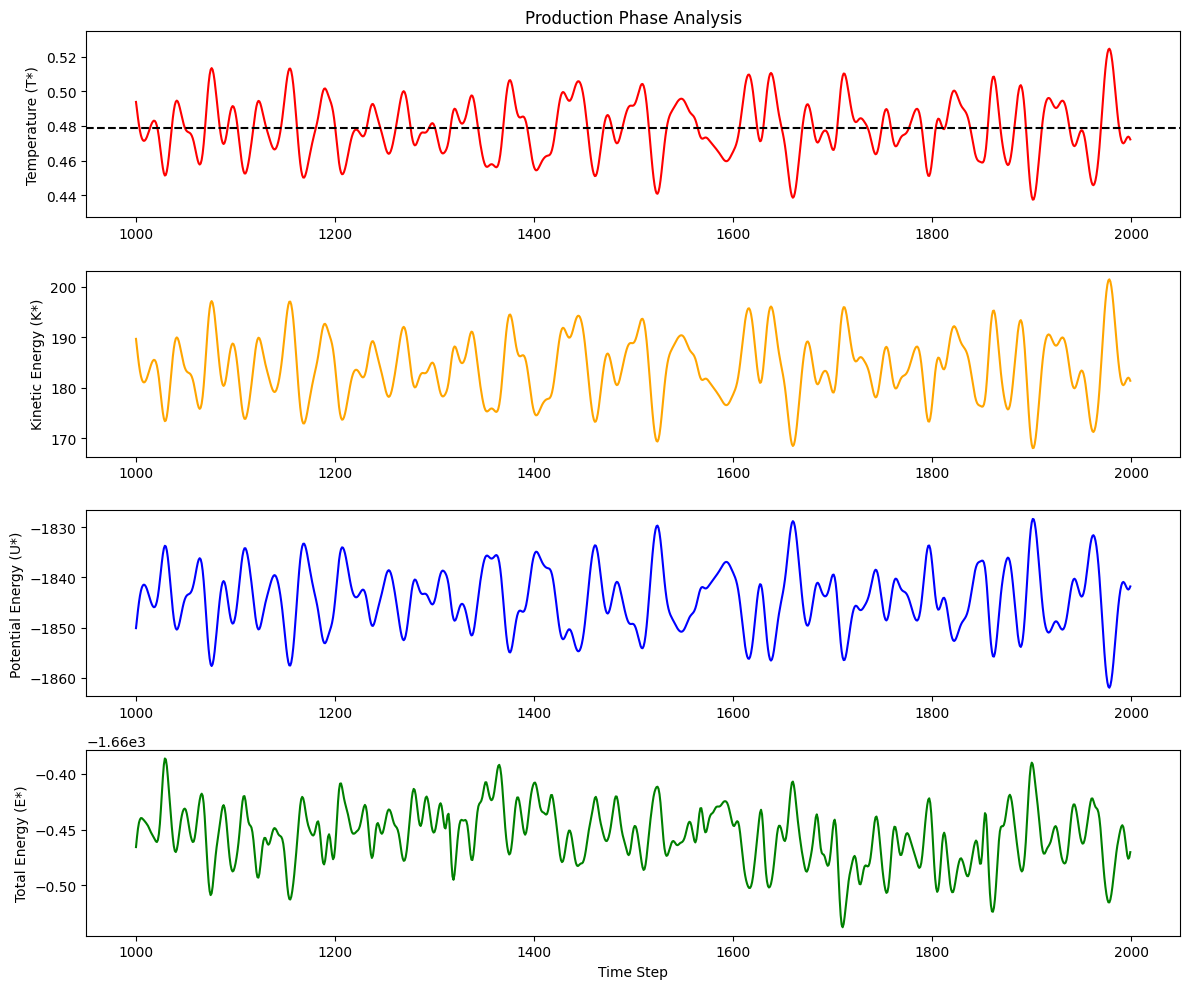

In [34]:
import matplotlib.pyplot as plt

# Production step numbers
steps = np.arange(len(T_list)) + 1000

# Total Energy
total_energy = np.array(K_list) + np.array(U_list)

plt.figure(figsize=(12, 10))

# -------------------------------------------------
# 1. Temperature
# -------------------------------------------------

plt.subplot(4, 1, 1)

plt.plot(steps, T_list, color='red')

plt.axhline(
    y=np.mean(T_list),
    color='black',
    linestyle='--'
)

plt.ylim(
    min(T_list) - 0.01,
    max(T_list) + 0.01
)

plt.ylabel('Temperature (T*)')

plt.title('Production Phase Analysis')

# -------------------------------------------------
# 2. Kinetic Energy
# -------------------------------------------------

plt.subplot(4, 1, 2)

plt.plot(steps, K_list, color='orange')

plt.ylabel('Kinetic Energy (K*)')

# -------------------------------------------------
# 3. Potential Energy
# -------------------------------------------------

plt.subplot(4, 1, 3)

plt.plot(steps, U_list, color='blue')

plt.ylabel('Potential Energy (U*)')

# -------------------------------------------------
# 4. Total Energy
# -------------------------------------------------

plt.subplot(4, 1, 4)

plt.plot(steps, total_energy, color='green')

plt.ylabel('Total Energy (E*)')

plt.xlabel('Time Step')

plt.tight_layout()

plt.show()

OBSERVATION:
 The instantaneous temperature fluctuated around the target value T
∗
=0.5, confirming correct velocity initialization and equilibration. The total energy remained approximately conserved during the production phase, demonstrating the stability and correctness of the Velocity Verlet integrator. The potential energy exhibited bounded thermal fluctuations without numerical divergence, indicating stable Lennard-Jones interactions and proper implementation of periodic boundary conditions and neighbor lists.

In [35]:
import numpy as np

bin_size = 50

U_list = np.array(U_list)

n_bins = len(U_list) // bin_size
U_binned = U_list[:n_bins * bin_size].reshape(n_bins, bin_size)

bin_means = np.mean(U_binned, axis=1)

mean_U = np.mean(bin_means)
error_U = np.std(bin_means) / np.sqrt(n_bins)

print("Mean U:", mean_U)
print("Error in U:", error_U)

Mean U: -1844.3063217629958
Error in U: 0.37888600399144096


In [36]:
import numpy as np

bin_size = 50

T_list = np.array(T_list)

n_bins = len(T_list) // bin_size
T_binned = T_list[:n_bins * bin_size].reshape(n_bins, bin_size)

bin_means = np.mean(T_binned, axis=1)

mean_T = np.mean(bin_means)
error_T = np.std(bin_means) / np.sqrt(n_bins)

print("Mean T:", mean_T)
print("Error in T:", error_T)

Mean T: 0.4787792306232771
Error in T: 0.0009827549857545166


In [37]:
import numpy as np

bin_size = 50

K_list = np.array(K_list)

n_bins = len(K_list) // bin_size
K_binned = K_list[:n_bins * bin_size].reshape(n_bins, bin_size)

bin_means = np.mean(K_binned, axis=1)

mean_K = np.mean(bin_means)
error_K = np.std(bin_means) / np.sqrt(n_bins)

print("Mean K:", mean_K)
print("Error in K:", error_K)

Mean K: 183.8512245593384
Error in K: 0.3773779145297357


STRUCTURAL ANALYSIS: using the radial distribution function g(r)
$$
g(r) = \frac{V}{4\pi r^2 N^2}
\left\langle
\sum_i \sum_{j \ne i} \delta(r-r_{ij})
\right\rangle
$$

1) Solid: Shows sharp, distinct peaks corresponding to shells of neighbors in a lattice.

2) Liquid: Shows broad, decaying peaks that eventually asymptote to 1.0, indicating no long-range
order.

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_rdf(pos, box_length, dr, r_max):
    """
    Calculates the Radial Distribution Function g(r)

    pos: (N,3) array of positions
    box_length: simulation box length (L)
    dr: bin width
    r_max: maximum distance (usually L/2)
    """

    N = len(pos)
    V = box_length**3
    rho = N / V

    nbins = int(r_max / dr)
    hist = np.zeros(nbins)


    for i in range(N):
        for j in range(i + 1, N):

            rij = pos[i] - pos[j]


            rij = rij - box_length * np.round(rij / box_length)

            r = np.linalg.norm(rij)


            if r < r_max:
                bin_index = min(int(r / dr), nbins - 1)
                hist[bin_index] += 2


    g_r = np.zeros(nbins)
    r_values = np.zeros(nbins)

    for k in range(nbins):
        r = (k + 0.5) * dr
        shell_volume = 4 * np.pi * r**2 * dr

        g_r[k] = hist[k] / (rho * N * shell_volume)
        r_values[k] = r

    return r_values, g_r

FINAL TASK:
 1. Run a simulation starting from an fcc lattice at T* = 0.2.
 2. Increase temperature in steps (0.2 -> 0.4 -> 0.6 -> 0.8 -> 1.0) .
 3. For each temperature , equilibrate and then collect g(r) data .
 4. Plot all g(r) curves on one graph .

I will wrap my MD simulation in a temperature loop

I will start the loop from T*=0.01 to show the transition from a solid to a liquid


Running simulation at T* = 0.01

Running simulation at T* = 0.1

Running simulation at T* = 0.2

Running simulation at T* = 0.4

Running simulation at T* = 0.6

Running simulation at T* = 0.8

Running simulation at T* = 1.0


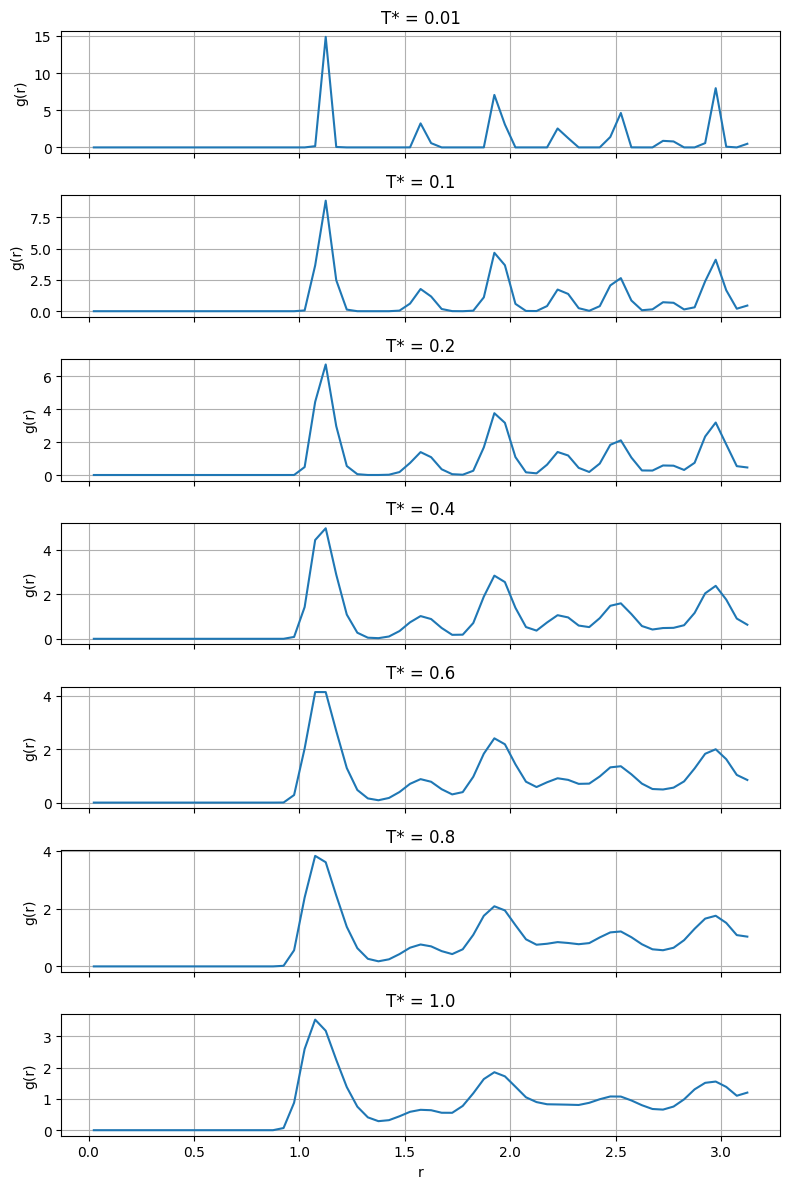

In [39]:



# -------------------------------------------------
# TEMPERATURE LOOP
# -------------------------------------------------

temperatures = [0.01,0.1,0.2, 0.4, 0.6, 0.8, 1.0]

all_rdf = []

# Common simulation parameters
n_cells = 4
rho_star = 1
dt = 0.005
skin = 0.3

for T_target in temperatures:

    print(f"\nRunning simulation at T* = {T_target}")

    # -------------------------------------------------
    # INITIALIZATION
    # -------------------------------------------------

    pos = generate_fcc_lattice(n_cells, rho_star)

    N = len(pos)

    box_length = (N / rho_star)**(1/3)

    vel = initialize_velocities(N, T_target)

    r_cutoff = box_length / 2.0

    r_cutoff_sq = r_cutoff**2

    neighbor_pairs = update_neighbor_list(
        pos,
        box_length,
        r_cutoff,
        (r_cutoff + skin)**2
    )

    pos_ref = pos.copy()

    force = calculate_forces_optimized(
        pos,
        neighbor_pairs,
        box_length,
        r_cutoff_sq
    )

    # -------------------------------------------------
    # RDF PARAMETERS
    # -------------------------------------------------

    dr = 0.05

    r_max = box_length / 2.0

    rdf_sum = None

    rdf_samples = 0

    # -------------------------------------------------
    # MAIN MD LOOP
    # -------------------------------------------------

    total_steps = 2000

    equil_limit = 1000

    for step in range(total_steps):

        # ---------------------------------------------
        # Velocity Verlet
        # ---------------------------------------------

        pos, vel, force = velocity_verlet_step(
            pos,
            vel,
            force,
            dt,
            box_length,
            neighbor_pairs,
            r_cutoff_sq
        )

        # ---------------------------------------------
        # Neighbor list update
        # ---------------------------------------------

        max_disp = compute_max_displacement(
            pos,
            pos_ref,
            box_length
        )

        if max_disp > (skin / 2):

            neighbor_pairs = update_neighbor_list(
                pos,
                box_length,
                r_cutoff,
                (r_cutoff + skin)**2
            )

            pos_ref = pos.copy()

            force = calculate_forces_optimized(
                pos,
                neighbor_pairs,
                box_length,
                r_cutoff_sq
            )

        # ---------------------------------------------
        # EQUILIBRATION
        # First 1000 steps
        # ---------------------------------------------

        if step < equil_limit:

            if step % 10 == 0:

                vel = rescale_velocities(
                    vel,
                    T_target
                )

        # ---------------------------------------------
        # PRODUCTION
        # Last 1000 steps
        # ---------------------------------------------

        else:

            # Collect RDF every 20 steps
            if step % 20 == 0:

                r_values, g_r = calculate_rdf(
                    pos,
                    box_length,
                    dr,
                    r_max
                )

                if rdf_sum is None:

                    rdf_sum = np.zeros_like(g_r)

                rdf_sum += g_r

                rdf_samples += 1

    # -------------------------------------------------
    # Average RDF
    # -------------------------------------------------

    avg_rdf = rdf_sum / rdf_samples

    all_rdf.append((T_target, r_values, avg_rdf))


# -------------------------------------------------
# FINAL PLOT
# -------------------------------------------------

fig, axes = plt.subplots(
    len(temperatures),
    1,
    figsize=(8, 12),
    sharex=True
)

for i, (T, r_values, g_r) in enumerate(all_rdf):

    axes[i].plot(r_values, g_r)

    axes[i].set_ylabel("g(r)")

    axes[i].set_title(f"T* = {T}")

    axes[i].grid()

axes[-1].set_xlabel("r")


plt.tight_layout()

plt.show()

OBSERVATION:
As we transition from lower temperatures to higher temperatures, we notice the peaks getting broad indicating no long range order. The first peak here corresponds to the first coordination shell. It signifies the most probable distance at which we will find the closest neighbouring atom, relative to the central reference atom.

For a solid: here as we have a FCC structure there will be peaks at rnn(nearest neighbour distance), next peak at root2*rnn and so on.

For a liquid: there is a large nearest-neighbor
peak and an oscillatory pattern at longer distances that asymptotes to a value of 1

**CHECKING FOR ARGON:**


In [40]:
from scipy.signal import find_peaks

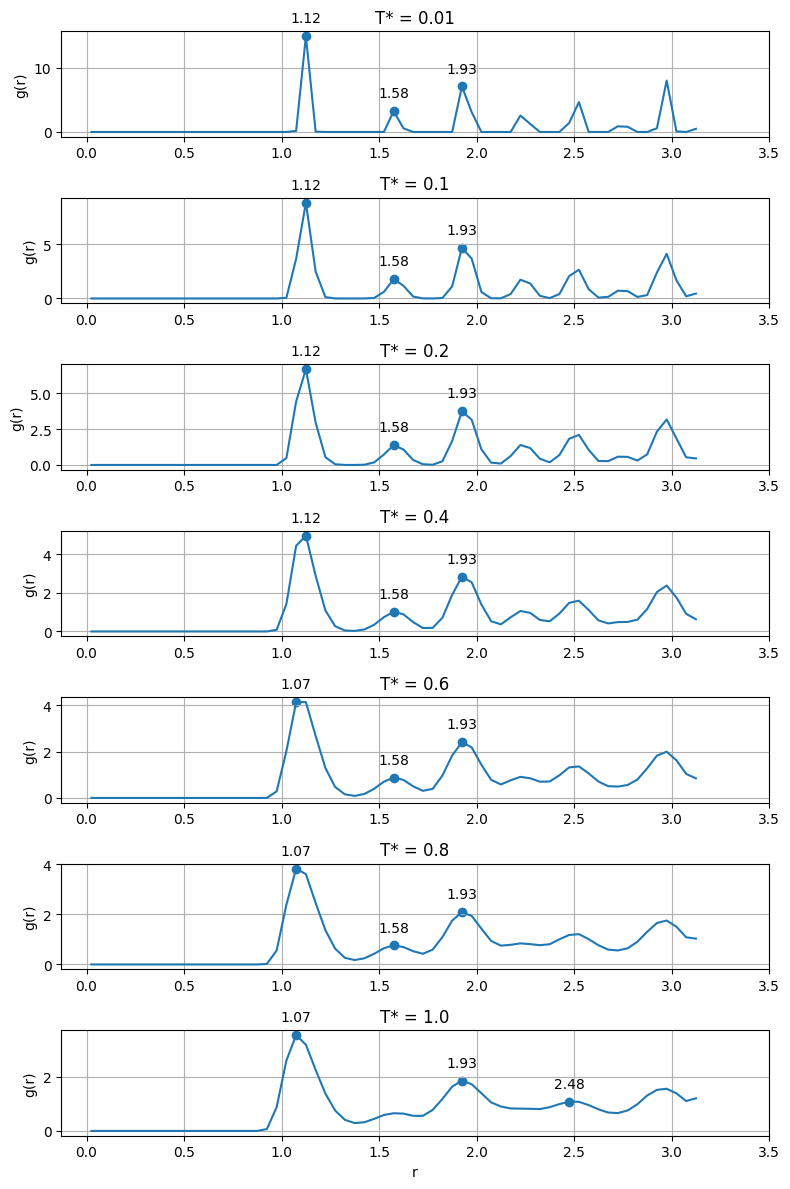

In [41]:
fig, axes = plt.subplots(
    len(temperatures),
    1,
    figsize=(8, 12),
    sharex=True
)

for i, (T, r_values, g_r) in enumerate(all_rdf):

    axes[i].plot(r_values, g_r)

    # -----------------------------------------
    # Find peaks
    # -----------------------------------------

    peaks, _ = find_peaks(
        g_r,
        prominence=0.2
    )

    # Take first 3 peaks
    first_three = peaks[:3]

    # Mark peaks
    axes[i].scatter(
        r_values[first_three],
        g_r[first_three]
    )

    # Label peaks
    for j, peak in enumerate(first_three):

        axes[i].annotate(
            f"{r_values[peak]:.2f}",
            (
                r_values[peak],
                g_r[peak]
            ),
            textcoords="offset points",
            xytext=(0,10),
            ha='center'
        )

    axes[i].set_ylabel("g(r)")

    axes[i].set_title(f"T* = {T}")

    axes[i].grid()

# x-axis ticks
for ax in axes:

    ax.set_xticks(
        np.arange(0, max(r_values)+0.5, 0.5)
    )

    ax.tick_params(
        axis='x',
        labelbottom=True
    )

axes[-1].set_xlabel("r")

plt.tight_layout()

plt.show()

Here our nearest neighbour distance at T*=0.01(which we will consider as solid) is given as 1.12, which means a/root2=1.12

calculating **a** we get it as 1.414*1.12=1.58368  (this is in reduced units)

for argon sigma=3.40 A

so lattice parameter=1.58368*3.40=5.38 ( which approximately matches the experimental value)

The epsilon value for argon=0.0104,
for T*=0.6
Treal=T*(epsilon/Kb)=0.6(120.69)=72.41 kelvin, this is the temperature where we notice even according to the graph that argon is transitioning into liquid state.

We notice that as the temp rises, the peaks broaden and Argon shifts into liquid state.


ADDITIONAL CHECKLIST FOR THE PROJECT:


Does total linear momentum remain at 0?

In [42]:
P = np.sum(vel, axis=0)
print("Momentum:", P) #yes

Momentum: [-3.49720253e-15 -1.07469589e-13 -8.88421281e-14]


Are total energy fluctuations less than 1 part in 104
?

In [43]:
E = np.array(K_list) + np.array(U_list)

rel_fluct = np.std(E) / np.mean(E) #yes

print("Relative fluctuation:", rel_fluct)

Relative fluctuation: -1.5280865224489093e-05


Does the Radial Distribution Function g(r) asymptotically reach 1.0 at large r?

In [44]:
tail = g_r[int(0.8 * len(g_r)):]
print("g(r) at large r:", np.mean(tail))#yes

g(r) at large r: 1.0748067825424719
